In [188]:
import warnings
warnings.filterwarnings("ignore")

In [189]:
import numpy as np
import pandas as pd
import libpysal
from spreg import OLS, GM_Error

df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
# df = df[df["in_metro"] == True].copy()
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
print(f"Metro tracts: {len(df)}")

# Outcome (focused on MHLTH only)
OUTCOME = "mental_distress"  # MHLTH: % adults with frequent mental distress

# Exposures: RBE / MBE / RBE-MBE
EXPOSURES = [("resident_ndvi", "RBE"), ("mobility_ndvi", "MBE"),
             ("diff_ndvi", "RBE-MBE")]

# Covariates: 11 ACS socioeconomic + 4 behavioral
ACS_PAPER = ["median_age", "median_income", "pop_density_sqmi", "pct_65plus",
             "pct_white_nh", "pct_black_nh", "pct_hispanic", "no_hs",
             "poverty_pct", "unemployment", "no_insurance", "no_vehicle_pct"]
BEH_ALL = [
    # "no_activity", 
    "smoking", 
    # "binge_drinking", 
    "poor_sleep"
    ]
ALL_COV = ACS_PAPER + BEH_ALL
print("n covariates:", len(ALL_COV))

Metro tracts: 82890
n covariates: 14


In [190]:
import statsmodels.api as sm

Xvif = df[ALL_COV].dropna().values.astype(float)
vif = {}
for i, c in enumerate(ALL_COV):
    y = Xvif[:, i]
    Xo = sm.add_constant(np.delete(Xvif, i, axis=1))
    r2 = sm.OLS(y, Xo).fit().rsquared
    vif[c] = 1 / (1 - r2)

vif_df = pd.DataFrame({"Variable": ALL_COV, "VIF": [vif[c] for c in ALL_COV]}) \
    .sort_values("VIF", ascending=False).round(3)
print(f"complete-case rows: {len(Xvif)}")
vif_df

complete-case rows: 82357


,Variable,VIF
4,pct_white_nh,9.176
6,pct_hispanic,8.348
5,pct_black_nh,5.747
12,smoking,4.695
10,no_insurance,4.554
0,median_age,4.545
3,pct_65plus,4.218
13,poor_sleep,4.011
7,no_hs,3.206
8,poverty_pct,2.828


In [191]:
# ===== Merge tract centroids for spatial weights =====
geo = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
geo["tract"] = geo["census_block_group"].str[:11]
cg = geo.groupby("tract").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
df = df.merge(cg, on="tract", how="left").dropna(subset=["lat"]).reset_index(drop=True)
print(f"With centroid: {len(df)}")

# Population weights (18+)
W = df["totalpop18plus"].values

def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))

# Population-weighted z-score standardization of exposures + covariates.
# For columns with missing values, compute weighted mean/SD on the non-NaN
# subset (NaN stays NaN; the model later fills NaN with 0 = mean after z-scoring).
df_s = df.copy()
for col in ["resident_ndvi", "mobility_ndvi", "diff_ndvi"] + ALL_COV:
    v = df[col].values
    ok = ~np.isnan(v)
    m = np.average(v[ok], weights=W[ok]) if ok.sum() > 0 else np.nan
    s = wstd(v[ok], W[ok]) if ok.sum() > 0 else np.nan
    df_s[col] = (v - m) / s if ok.sum() > 0 else v

def f0(x):
    return float(np.asarray(x).ravel()[0])

def star(p):
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))

def make_knn(sub, k=10):
    # Approximate metric projection -> KNN(k=10) row-standardized weights
    lat0 = np.radians(39.0)
    x = sub["lon"].values * 111320.0 * np.cos(lat0)
    y = sub["lat"].values * 110540.0
    w = libpysal.weights.KNN(np.column_stack([x, y]), k=k)
    w.transform = "r"
    return w

With centroid: 82890


In [192]:
# ===== 3 models (one per exposure), fully adjusted (ALL_COV), SEM =====

# Model 1 = RBE | Model 2 = MBE | Model 3 = RBE-MBE (no interaction term)
y = df[OUTCOME].values
mask = ~np.isnan(y)
ts = df[mask].reset_index(drop=True)
dss = df_s.loc[mask].reset_index(drop=True)
w2 = make_knn(ts)

def exposure_model(ex):
    X = np.nan_to_num(np.column_stack([dss[ex].values] +
                                      [dss[c].values for c in ALL_COV]), nan=0.0)
    names = [ex] + ALL_COV
    s = GM_Error(y[mask], X, w=w2, name_y="mhlth", name_x=names, vm=True)
    b = float(f0(s.betas[1])); se = float(f0(s.std_err[1])); p = float(s.z_stat[1][1])
    return b, se, b - 1.96 * se, b + 1.96 * se, f"{p:.2e}", star(p)

MODEL_LABELS = {0: "Model 1 (RBE)", 1: "Model 2 (MBE)", 2: "Model 3 (RBE-MBE)"}
rows = []
for j, (ex, _) in enumerate(EXPOSURES):
    eb, se, lo, hi, ep, es = exposure_model(ex)
    rows.append({"Model": MODEL_LABELS[j],
                 "Beta": round(eb, 4),
                 "95% CI": f"[{lo:.3f}, {hi:.3f}]",
                 "p": ep, "Sig": es})
int_df = pd.DataFrame(rows)
int_df

GM_Error
GM_Error
GM_Error


,Model,Beta,95% CI,p,Sig
0,Model 1 (RBE),-0.1231,"[-0.139, -0.107]",3.40e-52,***
1,Model 2 (MBE),-0.2177,"[-0.244, -0.192]",2.26e-60,***
2,Model 3 (RBE-MBE),-0.0424,"[-0.051, -0.033]",7.46e-21,***


In [193]:
from esda.moran import Moran

def sem_details(ex):
    y = df[OUTCOME].values
    mask = ~np.isnan(y)
    ts = df[mask].reset_index(drop=True)
    dss = df_s.loc[mask].reset_index(drop=True)
    w2 = make_knn(ts)
    X = np.nan_to_num(np.column_stack([dss[ex].values] + [dss[c].values for c in ALL_COV]), nan=0.0)
    names = [ex] + ALL_COV
    s = GM_Error(y[mask], X, w=w2, name_y="mhlth", name_x=names, vm=True)
    o = OLS(y[mask], X)                       # OLS baseline (AIC)
    lam = float(np.asarray(s.betas).ravel()[-1])   # spatial error lambda
    # Moran's I on SPATIALLY FILTERED residuals: eps = u - lambda * W@u.
    # (raw GM_Error residuals u still carry the lambda structure -> I~0.56;
    #  filtered eps should be ~white noise, I close to 0).
    u = np.asarray(s.u).ravel()
    eps = u - lam * np.asarray(w2.sparse.dot(u)).ravel()
    mi = Moran(eps, w2, permutations=99)      # Moran's I on filtered residuals
    nm = list(s.name_x)
    nz = len(s.z_stat)
    rows = []
    for i in range(nz):  # skip lambda row (no z-test)
        t = nm[i] if i < len(nm) else f"v{i}"
        b = float(s.betas[i])
        z = float(s.z_stat[i][0]); p = float(s.z_stat[i][1])
        rows.append({"Term": t, "Beta": round(b, 4), "SE": round(abs(b / z), 4),
                     "z": round(z, 3), "p": f"{p:.2e}", "Sig": star(p)})
    diag = {"lambda": round(lam, 3), "Moran_I": round(mi.I, 3),
            "Moran_p": f"{mi.p_sim:.3f}", "AIC_OLS": int(round(float(o.aic)))}
    return pd.DataFrame(rows), diag

for ex, exlab in EXPOSURES:
    det, dg = sem_details(ex)
    print(f"\n===== Model: {exlab} (exposure = {ex}) =====")
    print(f"lambda={dg['lambda']} (p<0.0001) | Moran's I (filtered resid.)={dg['Moran_I']} (p={dg['Moran_p']}) | AIC={dg['AIC_OLS']:,} (OLS)")
    print(det.to_string(index=False))

GM_Error

===== Model: RBE (exposure = resident_ndvi) =====
lambda=0.705 (p<0.0001) | Moran's I (filtered resid.)=0.025 (p=0.010) | AIC=305,350 (OLS)
            Term    Beta     SE        z         p Sig
        CONSTANT 16.8859 0.0138 1221.667  0.00e+00 ***
   resident_ndvi -0.1231 0.0081  -15.202  3.40e-52 ***
      median_age -0.7725 0.0088  -88.208  0.00e+00 ***
   median_income -0.3583 0.0079  -45.129  0.00e+00 ***
pop_density_sqmi  0.0891 0.0095    9.402  5.35e-21 ***
      pct_65plus -0.1393 0.0087  -16.105  2.37e-58 ***
    pct_white_nh  0.6729 0.0185   36.298 1.74e-288 ***
    pct_black_nh -0.3045 0.0138  -22.064 6.97e-108 ***
    pct_hispanic -0.0964 0.0173   -5.581  2.39e-08 ***
           no_hs -0.1074 0.0087  -12.335  5.83e-35 ***
     poverty_pct  0.5788 0.0070   82.654  0.00e+00 ***
    unemployment  0.0526 0.0045   11.759  6.35e-32 ***
    no_insurance  0.5821 0.0161   36.154 3.24e-286 ***
  no_vehicle_pct  0.0095 0.0082    1.160  2.46e-01    
         smoking  0.8799 

## Fig 1

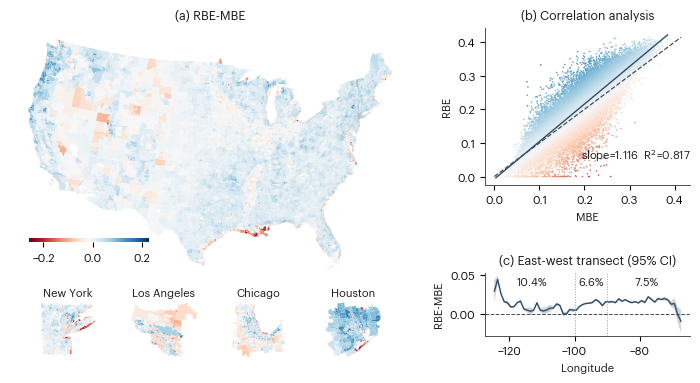

In [182]:
# ===== Figure 3: (a) RBE-MBE map + transect, (b) RBE vs MBE fit =====
# (a) choropleth of the greenness difference (RBE - MBE) across CONUS.
# (c) east-west transect of RBE-MBE (mean + 95% CI) by longitude, split into
#     West / Central / East zones labelled with the % by which RBE overestimates
#     MBE (100 * (mean RBE - mean MBE) / mean MBE, one decimal).
# (b) scatter of RBE vs MBE with a linear fit + R^2/p labels.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import statsmodels.api as sm

plt.rcParams.update({"font.family": GRAPHIK, "font.size": 8})

CONUS_EXCL = {"02", "15", "60", "66", "69", "72", "78"}   # exclude AK/HI/territories

fig = plt.figure(figsize=(9.5, 4.0))
gs = fig.add_gridspec(2, 2, width_ratios=[2.5, 1], height_ratios=[2.5, 1],
                      hspace=0.8, wspace=0.05)
axa = fig.add_subplot(gs[:, 0])    # (a) RBE-MBE map (full left column)
axb = fig.add_subplot(gs[0, 1])    # (b) fit lines (top-right)
axap = fig.add_subplot(gs[1, 1])   # (c) east-west transect (bottom-right)

# --- (a) RBE - MBE choropleth (Albers EPSG:5070, contiguous US) ---
plot_df = plot_df[~plot_df["tract"].str[:2].isin(CONUS_EXCL)]
plot_df.plot(column="diff_ndvi", cmap="RdBu", linewidth=0, ax=axa)
axa.set_title("(a) RBE-MBE", fontsize=9, color=INK)
axa.set_axis_off()
# Manual horizontal colorbar (inset lower-left). Build it ourselves so we can
# remove the outline via the official Colorbar.outline API.
_mappable = axa.collections[0]
_cb = fig.colorbar(_mappable, ax=axa, orientation="horizontal",
                   shrink=0.1, aspect=30, pad=0.03)
_cb.outline.set_edgecolor("none")     # hide the colorbar border
cax = _cb.ax
_pa = axa.get_position()
cax.set_position([_pa.x0 + 0.02, _pa.y0 + 0.08, 0.30 * _pa.width, 0.04 * _pa.height])

# --- (a'') 4 key-city zoomed insets below the map ---
import geopandas as gpd
from shapely.geometry import Point
CITIES = [("New York", (-74.01, 40.71), 90000.0),
          ("Los Angeles", (-118.24, 34.05), 90000.0),
          ("Chicago", (-87.63, 41.88), 90000.0),
          ("Houston", (-95.37, 29.76), 90000.0)]
_cc = gpd.GeoSeries([Point(lon, lat) for _, (lon, lat), _ in CITIES],
                    crs="EPSG:4326").to_crs("EPSG:5070")
for i, (nm, _, hw) in enumerate(CITIES):
    _cx, _cy = _cc.iloc[i].x, _cc.iloc[i].y
    _sub = plot_df.cx[_cx - hw:_cx + hw, _cy - hw:_cy + hw]
    if nm == "Los Angeles":
        _lat = _sub.geometry.centroid.to_crs("EPSG:4326").y
        _sub = _sub[_lat >= 33.5]
    _ax = fig.add_axes([0.17 + i * 0.1, 0.05, 0.15, 0.15])
    _sub.plot(column="diff_ndvi", cmap="RdBu", linewidth=0, ax=_ax)
    _ax.text(0.5, 1.2, nm, transform=_ax.transAxes, ha="center", va="top", fontsize=8, color=INK)
    _ax.set_axis_off()

# --- (c) East-west transect of RBE-MBE: mean + 95% CI vs longitude ----
# Bin CONUS tracts by longitude, plot the mean RBE-MBE with a 95% CI band, and
# split into 3 zones (West / Central / East) labelled with the % by which RBE
# overestimates MBE (100 * (mean RBE - mean MBE) / mean MBE, one decimal).
cgd = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
cgd["tract"] = cgd["census_block_group"].str[:11]
tlon = cgd.groupby("tract")["longitude"].mean()
p = plot_df[["tract", "resident_ndvi", "mobility_ndvi", "diff_ndvi"]].copy()
p["lon"] = p["tract"].map(tlon)
p = p.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi", "lon"]).copy()
p["lon_bin"] = pd.cut(p["lon"], bins=np.linspace(-126, -66, 61))
tr = p.groupby("lon_bin", observed=False)["diff_ndvi"].agg(["mean", "sem", "count"])
tr["ci"] = 1.96 * tr["sem"]                       # 95% CI of the mean
xc = [iv.mid for iv in tr.index]
# 3 longitudinal zones: West (-126,-100) | Central (-100,-90) | East (-90,-66)
ZONEB = [("West", -126, -100), ("Central", -100, -90), ("East", -90, -66)]
# for _, lo, hi in ZONEB:
#     axap.axvspan(lo, hi, color="#f2f2f0", zorder=0)
axap.plot(xc, tr["mean"].values, color="#2f4c6d", lw=1)
axap.fill_between(xc, tr["mean"].values - tr["ci"].values,
                  tr["mean"].values + tr["ci"].values,
                  color="#2f4c6d", alpha=0.25, edgecolor="none")
axap.axhline(0, color="#4d4d4d", lw=0.7, ls="--")
for b in (-100, -90):                             # zone separators
    axap.axvline(b, color="#9e9e9e", lw=0.7, ls=":")
# % RBE exceeds MBE within each zone (aggregate means, one decimal)
for lab, lo, hi in ZONEB:
    z = p[(p["lon"] >= lo) & (p["lon"] < hi)]
    pct = 100.0 * (z["resident_ndvi"].mean() - z["mobility_ndvi"].mean()) / z["mobility_ndvi"].mean()
    axap.text((lo + hi) / 2, 0.94, f"{pct:.1f}%",
              transform=axap.get_xaxis_transform(), ha="center", va="top",
              fontsize=8, color=INK, zorder=5)
axap.set_xlabel("Longitude")
axap.set_ylabel("RBE-MBE")
axap.set_title("(c) East-west transect (95% CI)", fontsize=9, color=INK)
for s_ in ("top", "right"):
    axap.spines[s_].set_visible(False)

# --- (b) RBE vs MBE scatter with linear fit (relationship between the two) ---
d2 = ds.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).copy()
x = d2["mobility_ndvi"].values   # MBE on x
y = d2["resident_ndvi"].values   # RBE on y
col = d2["diff_ndvi"].values     # colour by RBE - MBE (red: RBE>MBE, blue: MBE>RBE)
sc = axb.scatter(x, y, s=1.2, c=col, cmap="RdBu", alpha=0.75, linewidths=0)
# 1:1 (45-degree) reference line: y = x
_lo = min(x.min(), y.min()); _hi = max(x.max(), y.max())
axb.plot([_lo, _hi], [_lo, _hi], ls="--", color="#4d4d4d", lw=0.9, zorder=1)
Xc = sm.add_constant(x)
m = sm.OLS(y, Xc).fit()
xs = np.linspace(x.min(), x.max(), 50)
axb.plot(xs, m.params[0] + m.params[1] * xs, color="#2f4c6d", lw=1)
axb.text(xs[5]+0.15, m.params[0] + m.params[1] * xs[5] + 0.01,
         f"slope={m.params[1]:.3f}  R$^2$={m.rsquared:.3f}",
         fontsize=8)

axb.set_xlabel("MBE")
axb.set_ylabel("RBE")
axb.set_title("(b) Correlation analysis", fontsize=9, color=INK)
for s_ in ("top", "right"):
    axb.spines[s_].set_visible(False)

plt.savefig("figure3_rbe_mbe_fit.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [207]:
# ===== Table: descriptive statistics of RBE, MBE and RBE-MBE =====
# Overall population-weighted stats + stratified by RBE-MBE quartile.
import numpy as np
import pandas as pd
from IPython.display import display

df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
W = df["totalpop18plus"].values

def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))

# ---- overall (population-weighted) ----
ov = []
for col, lab in [("resident_ndvi", "RBE"), ("mobility_ndvi", "MBE"), ("diff_ndvi", "RBE-MBE")]:
    v = df[col].values
    ov.append([lab, round(np.average(v, weights=W), 4), round(wstd(v, W), 4),
               round(v.min(), 4), round(np.percentile(v, 25), 4), round(np.median(v), 4),
               round(np.percentile(v, 75), 4), round(v.max(), 4)])
ov_df = pd.DataFrame(ov, columns=["Variable", "Weighted mean", "Weighted SD",
                                  "Min", "P25", "Median", "P75", "Max"])

# ---- by RBE-MBE quartile ----
df["diff_q"] = pd.qcut(df["diff_ndvi"].values, 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
grp = []
for q in ["Q1", "Q2", "Q3", "Q4"]:
    sub = df[df["diff_q"] == q]; w = sub["totalpop18plus"].values
    r, m, d = sub["resident_ndvi"].values, sub["mobility_ndvi"].values, sub["diff_ndvi"].values
    grp.append([q, len(sub),
                f"{np.average(r, weights=w):.3f} ± {wstd(r, w):.3f}",
                f"{np.average(m, weights=w):.3f} ± {wstd(m, w):.3f}",
                f"{np.average(d, weights=w):.4f} ± {wstd(d, w):.4f}"])
grp_df = pd.DataFrame(grp, columns=["Quartile", "n",
                                    "RBE (mean ± SD)", "MBE (mean ± SD)", "RBE-MBE (mean ± SD)"])

print(f"N = {len(df):,} tracts")
display(ov_df)
display(grp_df)

N = 82,890 tracts


,Variable,Weighted mean,Weighted SD,Min,P25,Median,P75,Max
0,RBE,0.2110,0.0732,0.0000,0.1595,0.2194,0.2670,0.4141
1,MBE,0.1944,0.0595,0.0035,0.1558,0.2042,0.2390,0.3845
2,RBE-MBE,0.0165,0.0310,-0.2584,-0.0031,0.0154,0.0345,0.2290


,Quartile,n,RBE (mean ± SD),MBE (mean ± SD),RBE-MBE (mean ± SD)
0,Q1,20724,0.145 ± 0.062,0.168 ± 0.059,-0.0228 ± 0.0220
1,Q2,20745,0.193 ± 0.063,0.186 ± 0.063,0.0065 ± 0.0053
2,Q3,20707,0.233 ± 0.056,0.208 ± 0.056,0.0246 ± 0.0054
3,Q4,20714,0.266 ± 0.051,0.212 ± 0.049,0.0535 ± 0.0176


## Figure 2

GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error
GM_Error


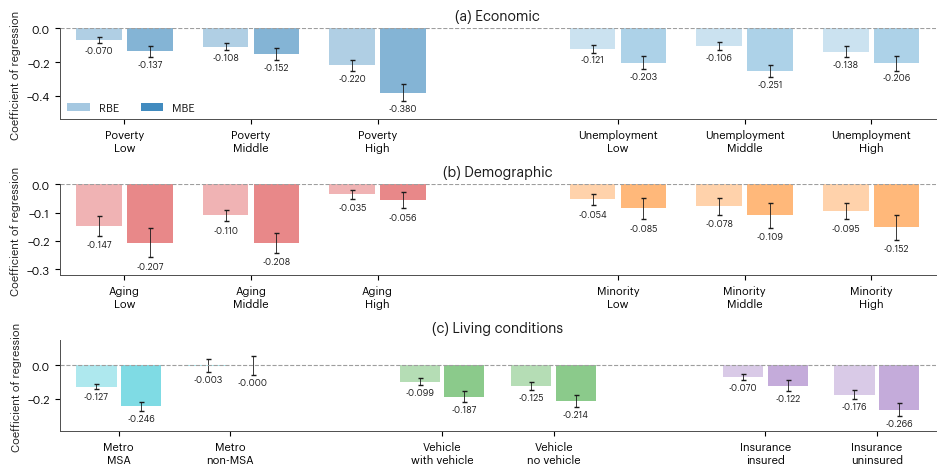

,panel,group,label,exposure,beta,95% CI,p,sig
0,(a) Economic,Poverty,Low,RBE,-0.0701,"[-0.089, -0.051]",0.0000,***
1,(a) Economic,Poverty,Low,MBE,-0.1368,"[-0.17, -0.103]",0.0000,***
2,(a) Economic,Poverty,Middle,RBE,-0.1076,"[-0.131, -0.084]",0.0000,***
3,(a) Economic,Poverty,Middle,MBE,-0.1522,"[-0.189, -0.115]",0.0000,***
4,(a) Economic,Poverty,High,RBE,-0.2196,"[-0.254, -0.185]",0.0000,***
5,(a) Economic,Poverty,High,MBE,-0.3796,"[-0.431, -0.328]",0.0000,***
6,(a) Economic,Unemployment,Low,RBE,-0.1207,"[-0.143, -0.098]",0.0000,***
7,(a) Economic,Unemployment,Low,MBE,-0.2030,"[-0.24, -0.166]",0.0000,***
8,(a) Economic,Unemployment,Middle,RBE,-0.1064,"[-0.13, -0.083]",0.0000,***
9,(a) Economic,Unemployment,Middle,MBE,-0.2511,"[-0.288, -0.214]",0.0000,***


In [129]:
# ===== Figure 7: grouped bar chart of effect modification (RBE + MBE) =====
# Three panels A/B/C; each grouping variable is a cluster, each subgroup shows
# TWO bars (RBE hollow, MBE solid) with 95% CI error bars and a zero line.
#   A Economic: poverty T1-T3, unemployment T1-T3
#   B Demographic: aging T1-T3, minority T1-T3
#   C Living: metro/non, vehicle, insurance
# Each stratified SEM (GM_Error, KNN k=10, pop-weighted z) drops the grouping
# variable's covariate from X.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import libpysal
from spreg import GM_Error
import warnings; warnings.filterwarnings("ignore")

df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
OUTCOME = "mental_distress"
ACS_PAPER = ["median_age", "median_income", "pop_density_sqmi", "pct_65plus",
             "pct_white_nh", "pct_black_nh", "pct_hispanic", "no_hs",
             "poverty_pct", "unemployment", "no_insurance", "no_vehicle_pct"]
ALL_COV = ACS_PAPER + ["smoking", "poor_sleep"]

geo = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
geo["tract"] = geo["census_block_group"].str[:11]
cg = geo.groupby("tract").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
df = df.merge(cg, on="tract", how="left").dropna(subset=["lat"]).reset_index(drop=True)

W = df["totalpop18plus"].values
def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))
df_s = df.copy()
for col in ["resident_ndvi", "mobility_ndvi"] + ALL_COV:
    v = df[col].values; ok = ~np.isnan(v)
    m = np.average(v[ok], weights=W[ok]) if ok.sum() > 0 else np.nan
    s = wstd(v[ok], W[ok]) if ok.sum() > 0 else np.nan
    df_s[col] = (v - m) / s if ok.sum() > 0 else v

def make_knn(sub, k=10):
    lat0 = np.radians(39.0)
    x = sub["lon"].values * 111320.0 * np.cos(lat0)
    y = sub["lat"].values * 110540.0
    w = libpysal.weights.KNN(np.column_stack([x, y]), k=k)
    w.transform = "r"
    return w

def star(pv):
    return "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))

y = df[OUTCOME].values
y_ok = ~np.isnan(y)

# ---- group specifications ----
def tertile(v):
    # semantic labels (no T1/T2/T3): Low / Middle / High
    q = pd.qcut(v, 3, labels=False, duplicates="drop")
    return [("Low", q == 0), ("Middle", q == 1), ("High", q == 2)]
def halve(v, lab_lo, lab_hi):
    med = np.median(v)
    return [(lab_lo, v <= med), (lab_hi, v > med)]

minority = (100.0 - df["pct_white_nh"].fillna(df["pct_white_nh"].median())).values
veh = df["no_vehicle_pct"].fillna(df["no_vehicle_pct"].median()).values
ins = df["no_insurance"].fillna(df["no_insurance"].median()).values
metro = (df["in_metro"].astype(str).str.strip() == "True").values

PANELS = [
    ("(a) Economic", [
        ("Poverty", tertile(df["poverty_pct"].fillna(df["poverty_pct"].median()).values), "poverty_pct"),
        ("Unemployment", tertile(df["unemployment"].fillna(df["unemployment"].median()).values), "unemployment"),
    ]),
    ("(b) Demographic", [
        ("Aging (65+)", tertile(df["pct_65plus"].fillna(df["pct_65plus"].median()).values), "pct_65plus"),
        ("Minority (non-White)", tertile(minority), "pct_white_nh"),
    ]),
    ("(c) Living conditions", [
        ("Metro status", [("MSA", metro), ("non-MSA", ~metro)], None),
        ("Vehicle access", halve(veh, "with vehicle", "no vehicle"), "no_vehicle_pct"),
        ("Insurance", halve(ins, "insured", "uninsured"), "no_insurance"),
    ]),
]

# ---- run all stratified SEM models (RBE and MBE) ----
res = []
for pname, specs in PANELS:
    for gname, groups, drop in specs:
        cov_model = [c for c in ALL_COV if c != drop]
        for glab, gflag in groups:
            gm = gflag & y_ok
            if gm.sum() < 200:
                continue
            ts = df.loc[gm].reset_index(drop=True)
            dss = df_s.loc[gm].reset_index(drop=True)
            w2 = make_knn(ts)
            for ex, exp_lab in [("resident_ndvi", "RBE"), ("mobility_ndvi", "MBE")]:
                X = np.nan_to_num(np.column_stack([dss[ex].values] +
                                                  [dss[c].values for c in cov_model]), nan=0.0)
                s = GM_Error(y[gm], X, w=w2, name_y="mhlth", name_x=[exp_lab] + cov_model, vm=True)
                b = float(np.asarray(s.betas).ravel()[1])
                se = float(np.sqrt(np.diag(np.asarray(s.vm)))[1])
                p = float(np.asarray(s.z_stat)[1, 1])
                res.append({"panel": pname, "group": gname, "label": glab,
                            "exposure": exp_lab, "beta": b, "se": se, "p": p,
                            "lo": b - 1.96 * se, "hi": b + 1.96 * se})
res = pd.DataFrame(res)

# ---- grouped bar chart (RBE hollow + MBE solid) ----
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import Patch
plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#4d4d4d",
                     "axes.labelcolor": "#1a1a1a", "text.color": "#1a1a1a",
                     "figure.facecolor": "#ffffff", "savefig.facecolor": "#ffffff",
                     "axes.linewidth": 0.7})
INK = "#1a1a1a"

# per-cluster base colours (RBE gets light shade/hollow, MBE gets dark/solid)
PAL = {
    ("(a) Economic", "Poverty"): "#1f77b4",
    ("(a) Economic", "Unemployment"): "#6baed6",
    ("(b) Demographic", "Aging (65+)"): "#d62728",
    ("(b) Demographic", "Minority (non-White)"): "#ff7f0e",
    ("(c) Living conditions", "Metro status"): "#17becf",
    ("(c) Living conditions", "Vehicle access"): "#2ca02c",
    ("(c) Living conditions", "Insurance"): "#9467bd",
}
def shade(hexcol, f):
    base = np.array(mcolors.to_rgb(hexcol))
    return mcolors.to_hex(base + (1 - base) * f) if f >= 0 else mcolors.to_hex(base * (1 + f))

plt.close("all")
fig, axes = plt.subplots(3, 1, figsize=(9.5, 5))
BW = 0.36   # bar width per exposure
for ax, (pname, specs) in zip(axes, PANELS):
    sub = res[res["panel"] == pname]
    x = 0.0
    positions, xtick = [], []
    for gname, groups, drop in specs:
        base = PAL[(pname, gname)]
        for glab, gflag in groups:
            positions.append(x)
            xtick.append(f"{gname.split(' ')[0]}\n{glab}")
            for ex, off in [("RBE", -BW / 2 - 0.02), ("MBE", BW / 2 + 0.02)]:
                r = sub[(sub["group"] == gname) & (sub["label"] == glab) & (sub["exposure"] == ex)]
                if r.empty:
                    continue
                b, se, p = r["beta"].iloc[0], r["se"].iloc[0], r["p"].iloc[0]
                # RBE vs MBE are the SAME base colour, distinguished by transparency
                alpha = 0.35 if ex == "RBE" else 0.55
                ax.bar(x + off, b, width=BW, color=base, alpha=alpha,
                       edgecolor=INK, linewidth=0,
                       yerr=1.96 * se, capsize=1.8, error_kw={"ecolor": INK, "lw": 0.6})
                # coefficient label centred on top of EACH bar (RBE and MBE aligned)
                cap = 1.96 * se
                ylab = b + cap + 0.016 if b >= 0 else b - cap - 0.016
                ax.text(x + off, ylab, f"{b:.3f}",
                        ha="center", va="bottom" if b >= 0 else "top",
                        fontsize=6.5, color=INK)
            x += 1.0
        x += 0.9   # gap between clusters
    ax.axhline(0, color="#9e9e9e", lw=0.8, ls="--")
    ax.set_xticks(positions)
    ax.set_xticklabels(xtick, fontsize=8)
    ax.set_ylabel("Coefficient of regression")
    ax.set_title(pname, fontsize=10, color=INK, pad=6)
    ax.margins(x=0.02, y=0.25)   # a bit more vertical room so labels don't clip
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

# shared legend (RBE vs MBE, same base colour, transparency distinguishes them)
handles = [Patch(fc="#1f77b4", alpha=0.40, label="RBE"),
           Patch(fc="#1f77b4", alpha=0.85, label="MBE")]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, fontsize=8,
           bbox_to_anchor=(0.14, 0.77))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figure7_effect_modification_bars.jpg", dpi=300, bbox_inches="tight")
plt.show()

# ---- results table with 95% CI ----
res["95% CI"] = "[" + res["lo"].round(3).astype(str) + ", " + res["hi"].round(3).astype(str) + "]"
res["sig"] = [star(p) for p in res["p"]]
res[["panel", "group", "label", "exposure", "beta", "95% CI", "p", "sig"]].round(4)


All tracts: 82,890 | MSA = 68,220 | non-MSA = 14,670
GM_Error
GM_Error
GM_Error
GM_Error


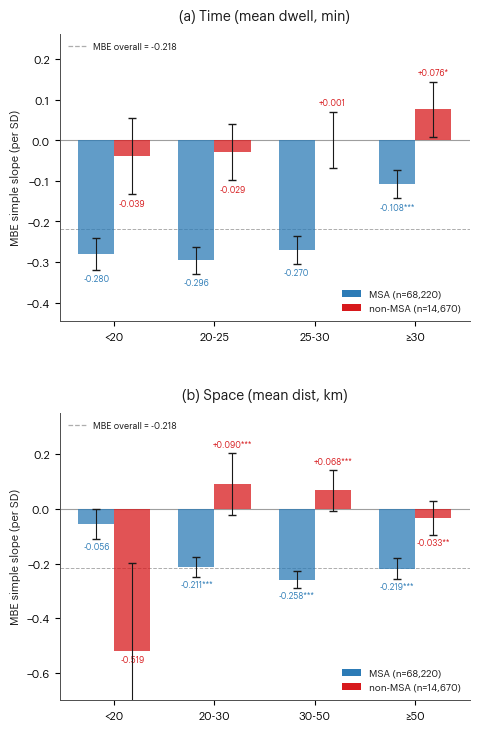

MBE simple slope by fixed bins (per SD, 95% CI) — MSA vs non-MSA:
Overall MBE main effect (full sample) = -0.218 | Overall RBE main effect = -0.123


(a) Time (mean dwell, min)  [dwell]
  --- MSA ---
    <20      (n=10,825): -0.2798  (95% CI [-0.319, -0.241])
    20-25    (n=26,438): -0.2958  (95% CI [-0.328, -0.263])
    25-30    (n=17,873): -0.2704  (95% CI [-0.304, -0.237])
    ≥30      (n=13,084): -0.1084  (95% CI [-0.143, -0.074])
    interaction p (vs lowest): D2 3.10e-01  D3 5.98e-01  D4 1.53e-19***
  --- non-MSA ---
    <20      (n=1,970): -0.0390  (95% CI [-0.133, 0.055])
    20-25    (n=5,443): -0.0286  (95% CI [-0.098, 0.041])
    25-30    (n=4,077): +0.0008  (95% CI [-0.068, 0.069])
    ≥30      (n=3,180): +0.0765  (95% CI [0.009, 0.144])
    interaction p (vs lowest): D2 8.02e-01  D3 3.73e-01  D4 1.38e-02*

(b) Space (mean dist, km)  [dist]
  --- MSA ---
    <20      (n=7,148): -0.0558  (95% CI [-0.110, -0.001])
    20-30    (n=22,129): -0.2114  (95% CI [-0.248, -0.175])
 

In [215]:
# ===== Figure: MBE interaction with movement — fixed bins, MSA vs non-MSA (bar) =====
# One column, two rows:
#   (a) top    = time dimension  (mean dwell, min)
#   (b) bottom = space dimension (mean dist, km)
# Fixed-threshold bins (same edges for both groups), 4 groups each:
#   dwell: <20 / 20-25 / 25-30 / >=30 min
#   dist : <20 / 20-30 / 30-50 / >=50 km
# For EACH panel we fit two SEPARATE SEM interaction models (ref = lowest bin):
#   MHLTH ~ MBE + D2..D4 + MBE x D2..D4 + 14 covariates
# run on the MSA subsample and on the non-MSA subsample; the two MBE simple
# slopes (95% CI) are drawn as SIDE-BY-SIDE BARS in different hues (MSA vs
# non-MSA). Two dashed reference lines mark the FULL-SAMPLE exposure main
# effects (MBE mean = -0.218, RBE mean = -0.123), labelled in the upper-left
# legend. Panel (b) y-limits fixed to [-0.7, 0.35]; because the non-MSA <20
# error bar extends below the axis, its value label is placed on the BAR TOP
# instead of below the error bar. Interaction significance vs the lowest bin
# is marked with stars on the bar labels (*** p<0.001, ** p<0.01, * p<0.05;
# the lowest bin i==0 is the reference and has no star).
# NOTE: population-weighted z-score is computed on the FULL sample so the two
# groups' slopes are on the same scale. All tracts are kept (no in_metro filter).
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import libpysal
from spreg import GM_Error
import warnings; warnings.filterwarnings("ignore")

# ---- Nature-style rcParams ----
font_manager.fontManager.addfont("../Graphik-Regular.ttf")
INK, MUTED = "#1a1a1a", "#6b6b6b"
plt.rcParams.update({
    "font.family": "Graphik", "font.size": 8,
    "axes.edgecolor": "#4d4d4d", "axes.linewidth": 0.7,
    "axes.labelcolor": INK, "text.color": INK,
    "figure.facecolor": "#ffffff", "savefig.facecolor": "#ffffff",
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# ---- data + population-weighted z-score standardization (FULL sample) ----
df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
df["_metro"] = (df["in_metro"].astype(str).str.strip() == "True").astype(int)
print(f"All tracts: {len(df):,} | MSA = {int(df['_metro'].sum()):,} | non-MSA = {int((df['_metro']==0).sum()):,}")
OUTCOME = "mental_distress"
ACS_PAPER = ["median_age", "median_income", "pop_density_sqmi", "pct_65plus",
             "pct_white_nh", "pct_black_nh", "pct_hispanic", "no_hs",
             "poverty_pct", "unemployment", "no_insurance", "no_vehicle_pct"]
ALL_COV = ACS_PAPER + ["smoking", "poor_sleep"]

geo = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
geo["tract"] = geo["census_block_group"].str[:11]
cg = geo.groupby("tract").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
df = df.merge(cg, on="tract", how="left").dropna(subset=["lat"]).reset_index(drop=True)

W = df["totalpop18plus"].values
def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))
df_s = df.copy()
for col in ["mobility_ndvi", "mean_dwell_min", "mean_dist_km"] + ALL_COV:
    v = df[col].values; ok = ~np.isnan(v)
    m = np.average(v[ok], weights=W[ok]) if ok.sum() > 0 else np.nan
    sv = wstd(v[ok], W[ok]) if ok.sum() > 0 else np.nan
    df_s[col] = (v - m) / sv if ok.sum() > 0 else v

def make_knn(sub, k=10):
    lat0 = np.radians(39.0)
    x = sub["lon"].values * 111320.0 * np.cos(lat0)
    y = sub["lat"].values * 110540.0
    w = libpysal.weights.KNN(np.column_stack([x, y]), k=k)
    w.transform = "r"
    return w

def star(pv):
    return "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))

y = df[OUTCOME].values; yok = ~np.isnan(y)

def bin_flags(v, edges):
    """Fixed-threshold bins -> list of 0/1 flags: [<e0, e0-e1, ..., >=eK]."""
    bounds = ([(-np.inf, edges[0])]
              + [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]
              + [(edges[-1], np.inf)])
    return [((v >= a) & (v < b)).astype(float) for a, b in bounds]

def fit_bin_subgroup(metro_flag, vcol, edges):
    """SEM interaction model (ref = lowest bin) for one metro subgroup."""
    sub = (df["_metro"] == metro_flag) & yok
    ts = df.loc[sub].reset_index(drop=True)
    dss = df_s.loc[sub].reset_index(drop=True)
    w2 = make_knn(ts)
    mbe = dss["mobility_ndvi"].values
    cov = [np.nan_to_num(dss[c].values, nan=0.0) for c in ALL_COV]
    v = ts[vcol].fillna(ts[vcol].median()).values
    flags = bin_flags(v, edges)
    K = len(flags)
    dums = flags[1:]
    cols = [mbe] + dums + [mbe * d for d in dums] + cov
    lab_cols = (["MBE"] + [f"D{i+2}" for i in range(K - 1)]
                + [f"MBE x D{i+2}" for i in range(K - 1)]
                + ["cov_" + str(i) for i in range(1, len(cov) + 1)])
    X = np.nan_to_num(np.column_stack(cols), nan=0.0)
    s = GM_Error(y[sub], X, w=w2, name_y="mhlth", name_x=lab_cols, vm=True)
    b = np.asarray(s.betas).ravel(); vm = np.asarray(s.vm)
    se = np.sqrt(np.diag(vm)); z = np.asarray(s.z_stat)

    def sse(i, j=None):
        return se[i] if j is None else np.sqrt(vm[i, i] + vm[j, j] + 2 * vm[i, j])

    int_idx = [K + (k - 1) for k in range(2, K + 1)]
    sl = [(b[1], sse(1))] + [(b[1] + b[ii], sse(1, ii)) for ii in int_idx]
    return {
        "slope": [x[0] for x in sl], "se": [x[1] for x in sl],
        "lo": [x[0] - 1.96 * x[1] for x in sl], "hi": [x[0] + 1.96 * x[1] for x in sl],
        "p_ints": [z[ii, 1] for ii in int_idx],
        "n": [int(f.sum()) for f in flags],
    }

# ---- fixed bin definitions (4 groups, same for MSA and non-MSA) ----
SPECS = [
    ("(a) Time (mean dwell, min)", "mean_dwell_min", "dwell", [20, 25, 30]),
    ("(b) Space (mean dist, km)", "mean_dist_km", "dist", [20, 30, 50]),
]
GROUPS = [("MSA", 1), ("non-MSA", 0)]
HCOL = {"MSA": "#2c7bb6", "non-MSA": "#d7191c"}
OVERALL_MBE = -0.218   # full-sample MBE main effect
OVERALL_RBE = -0.123   # full-sample RBE main effect

panels = []
for ptitle, vcol, tag, edges in SPECS:
    labs = ([f"<{edges[0]:.0f}"]
            + [f"{edges[i]:.0f}-{edges[i+1]:.0f}" for i in range(len(edges) - 1)]
            + [f"\u2265{edges[-1]:.0f}"])
    series = {}
    for gname, mflag in GROUPS:
        series[gname] = fit_bin_subgroup(mflag, vcol, edges)
    panels.append({"title": ptitle, "tag": tag, "labs": labs, "series": series})

# ---- one column, two rows (larger vertical gap between panels) ----
BW = 0.36                        # bar width (two bars side-by-side per bin)
offs = {"MSA": -BW / 2, "non-MSA": BW / 2}
fig, axes = plt.subplots(2, 1, figsize=(5, 7.4), sharex=False)
for ax, P in zip(axes, panels):
    xs = np.arange(len(P["labs"]))
    ax.axhline(0, color="#9e9e9e", lw=0.8, ls="-", zorder=1)
    # full-sample exposure main-effect reference lines (dashed, labelled in legend)
    ax.axhline(OVERALL_MBE, color="#adadad", lw=0.7, ls="--", zorder=1)
    # ax.axhline(OVERALL_RBE, color="#adadad", lw=0.7, ls=":", zorder=0)
    for gname in ["MSA", "non-MSA"]:
        S = P["series"][gname]; c = HCOL[gname]
        xb = xs + offs[gname]
        ax.bar(xb, S["slope"], width=BW, color=c, alpha=0.75, edgecolor="none",
               yerr=[[s - l for s, l in zip(S["slope"], S["lo"])],
                     [h - s for s, h in zip(S["slope"], S["hi"])]],
               capsize=3, error_kw={"ecolor": INK, "lw": 0.8}, zorder=3)
        # slope value label: the reference bin (i==0) has no star; for i>=1 the
        # significance of MBE x D(i+1) vs the lowest bin is shown as stars
        # (*** p<0.001, ** p<0.01, * p<0.05) appended to the value.
        for i, (s_, lo_, hi_) in enumerate(zip(S["slope"], S["lo"], S["hi"])):
            sig = "" if i == 0 else star(S["p_ints"][i - 1])
            if P["tag"] == "dist" and gname == "non-MSA" and i == 0:
                ylab, valign = s_ - 0.05, "bottom"      # on the BAR top
            elif s_ >= 0:
                ylab, valign = hi_ + 0.012, "bottom"     # on the bar top
            else:
                ylab, valign = lo_ - 0.012, "top"        # below the error bar
            ax.text(xb[i], ylab, f"{s_:+.3f}{sig}",
                    ha="center", va=valign, fontsize=6, color=c,
                    fontweight="bold" if sig else "normal")
    ax.set_xticks(xs)
    ax.set_xticklabels(P["labs"], fontsize=8)
    ax.set_ylabel("MBE simple slope (per SD)", fontsize=8)
    ax.set_title(P["title"], fontsize=10, color=INK, pad=10)
    ax.margins(y=0.25)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    # legend 1: MSA vs non-MSA (bars, bottom-right)
    leg_bars = ax.legend(handles=[Patch(fc=HCOL[g], ec="none", label=f"{g} (n={sum(P['series'][g]['n']):,})")
                                  for g in ["MSA", "non-MSA"]],
                         frameon=False, fontsize=7, loc="lower right")
    # legend 2: full-sample exposure-mean reference lines (top-left)
    leg_ref = ax.legend(handles=[Line2D([0], [0], color="#adadad", ls="--", lw=0.9,
                                        label=f"MBE overall = {OVERALL_MBE:.3f}"),
                                #  Line2D([0], [0], color="#adadad", ls=":", lw=0.9,
                                #         label=f"RBE overall = {OVERALL_RBE:.3f}")
                                        ],
                        frameon=False, fontsize=6.5, loc="upper left")
    ax.add_artist(leg_bars)      # keep BOTH legends (2nd legend would replace 1st)
    # panel (b): fix y-limits so the non-MSA <-20 outlier does not stretch the axis
    if P["tag"] == "dist":
        ax.set_ylim(-0.7, 0.35)

plt.subplots_adjust(left=0.15, right=0.97, top=0.95, bottom=0.05, hspace=0.32)
plt.savefig("figure9_mbe_mover_interaction_MSA.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("MBE simple slope by fixed bins (per SD, 95% CI) — MSA vs non-MSA:")
print(f"Overall MBE main effect (full sample) = {OVERALL_MBE:.3f} | Overall RBE main effect = {OVERALL_RBE:.3f}\n")
for P in panels:
    print(f"\n{P['title']}  [{P['tag']}]")
    for g in ["MSA", "non-MSA"]:
        S = P["series"][g]
        print(f"  --- {g} ---")
        for lb, s_, lo_, hi_, n in zip(P["labs"], S["slope"], S["lo"], S["hi"], S["n"]):
            print(f"    {lb:<8} (n={n:,}): {s_:+.4f}  (95% CI [{lo_:.3f}, {hi_:.3f}])")
        print(f"    interaction p (vs lowest): " +
              "  ".join(f"D{i+2} {p:.2e}{star(p)}" for i, p in enumerate(S["p_ints"])))

In [189]:
# ===== RBE coefficients within the 3 vulnerable MSA groups =====
# Same 3 vulnerable groups as the mobility-limitation figure (MSA only):
#   High poverty (T3) | Older (65+, T3) | No vehicle.
# For each group we fit the RBE (resident_ndvi) MAIN-EFFECT SEM:
#   MHLTH ~ RBE + 13 covariates   (the stratifying variable's covariate is dropped)
# within the group's subsample. GM_Error, KNN k=10, population-weighted z-score
# (computed on the MSA full sample). Reports beta / SE / 95% CI / z / p / n.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import libpysal
from spreg import GM_Error
import warnings; warnings.filterwarnings("ignore")

df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
df = df[df["in_metro"].astype(str).str.strip() == "True"].reset_index(drop=True)   # MSA only
print(f"MSA tracts: {len(df):,}")
OUTCOME = "mental_distress"
ACS_PAPER = ["median_age", "median_income", "pop_density_sqmi", "pct_65plus",
             "pct_white_nh", "pct_black_nh", "pct_hispanic", "no_hs",
             "poverty_pct", "unemployment", "no_insurance", "no_vehicle_pct"]
ALL_COV = ACS_PAPER + ["smoking", "poor_sleep"]
EXPOSURE = "resident_ndvi"   # RBE

geo = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
geo["tract"] = geo["census_block_group"].str[:11]
cg = geo.groupby("tract").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
df = df.merge(cg, on="tract", how="left").dropna(subset=["lat"]).reset_index(drop=True)

W = df["totalpop18plus"].values
def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))
df_s = df.copy()
for col in [EXPOSURE] + ALL_COV:
    v = df[col].values; ok = ~np.isnan(v)
    m = np.average(v[ok], weights=W[ok]) if ok.sum() > 0 else np.nan
    sv = wstd(v[ok], W[ok]) if ok.sum() > 0 else np.nan
    df_s[col] = (v - m) / sv if ok.sum() > 0 else v

def make_knn(sub, k=10):
    lat0 = np.radians(39.0)
    x = sub["lon"].values * 111320.0 * np.cos(lat0)
    y = sub["lat"].values * 110540.0
    w = libpysal.weights.KNN(np.column_stack([x, y]), k=k)
    w.transform = "r"
    return w

def star(pv):
    return "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))

y = df[OUTCOME].values; yok = ~np.isnan(y)

# ---- vulnerable flags (same definitions as the mobility-limitation figure) ----
pq = pd.qcut(df["poverty_pct"].fillna(df["poverty_pct"].median()), 3, labels=False, duplicates="drop")
aq = pd.qcut(df["pct_65plus"].fillna(df["pct_65plus"].median()), 3, labels=False, duplicates="drop")
pov_hi = (pq == 2).values                      # top tertile of poverty
old_hi = (aq == 2).values                      # top tertile of aging
no_veh = (df["no_vehicle_pct"].fillna(df["no_vehicle_pct"].median()) > df["no_vehicle_pct"].median()).values

DIMS = [
    ("High poverty (T3)", pov_hi, "poverty_pct"),
    ("Older (65+, T3)", old_hi, "pct_65plus"),
    ("No vehicle", no_veh, "no_vehicle_pct"),
]

print("\n" + "=" * 100)
print("RBE (resident_ndvi) main effect within vulnerable MSA groups  |  SEM GM_Error, KNN k=10, pop-weighted z")
print("=" * 100)
print(f"{'group':<20}{'n':>10}{'beta':>10}{'SE':>9}{'z':>9}{'95% CI':>24}{'p':>12}{'':>3}{'sig':>5}")
print("-" * 100)
rows = []
for dname, weak, vcol in DIMS:
    cov_model = [c for c in ALL_COV if c != vcol]          # drop the stratifying covariate
    sub_flag = weak & yok
    dfv = df.loc[sub_flag].reset_index(drop=True)
    dfv_s = df_s.loc[sub_flag].reset_index(drop=True)
    wv = make_knn(dfv)
    rbe = dfv_s[EXPOSURE].values
    covv = [np.nan_to_num(dfv_s[c].values, nan=0.0) for c in cov_model]
    X = np.nan_to_num(np.column_stack([rbe] + covv), nan=0.0)
    names = ["RBE"] + ["cov_" + str(i) for i in range(1, len(covv) + 1)]
    s = GM_Error(y[sub_flag], X, w=wv, name_y="mhlth", name_x=names, vm=True)
    b = float(np.asarray(s.betas).ravel()[1])
    se = float(np.sqrt(np.diag(np.asarray(s.vm)))[1])
    zz = float(np.asarray(s.z_stat)[1, 0]); p = float(np.asarray(s.z_stat)[1, 1])
    print(f"{dname:<20}{int(sub_flag.sum()):>10,}{b:>+10.4f}{se:>9.4f}{zz:>9.3f}"
          f"[{b - 1.96*se:+.3f}, {b + 1.96*se:+.3f}]{p:>12.2e}  {star(p):<5}")
    rows.append({"group": dname, "n": int(sub_flag.sum()), "beta": b, "se": se,
                 "lo": b - 1.96 * se, "hi": b + 1.96 * se, "z": zz, "p": p})
print("-" * 100)
print("Reference: RBE main effect, full MSA sample (Model 1) from the main table.")
print(pd.DataFrame(rows).round(4).to_string(index=False))

MSA tracts: 68,220

RBE (resident_ndvi) main effect within vulnerable MSA groups  |  SEM GM_Error, KNN k=10, pop-weighted z
group                        n      beta       SE        z                  95% CI           p     sig
----------------------------------------------------------------------------------------------------
GM_Error
High poverty (T3)       22,740   -0.2231   0.0193  -11.588[-0.261, -0.185]    4.75e-31  ***  
GM_Error
Older (65+, T3)         22,740   -0.0521   0.0085   -6.132[-0.069, -0.035]    8.69e-10  ***  
GM_Error
No vehicle              34,025   -0.1237   0.0122  -10.110[-0.148, -0.100]    4.98e-24  ***  
----------------------------------------------------------------------------------------------------
Reference: RBE main effect, full MSA sample (Model 1) from the main table.
            group     n    beta     se      lo      hi        z   p
High poverty (T3) 22740 -0.2231 0.0193 -0.2608 -0.1853 -11.5878 0.0
  Older (65+, T3) 22740 -0.0521 0.0085 -0.0687 -0.0

In [217]:
# ===== RBE by travel-distance group: STRATIFIED regressions (vulnerable MSA groups) =====
# 按出行距离分组做独立回归（不加交互项）：
#   每个距离 bin（<20 / 20-30 / 30-50 / >=50 km）内单独拟合
#   MHLTH ~ RBE + 13 covariates   (SEM GM_Error, KNN k=10)
# z-score 在 MSA 全样本上计算（保证组间系数在同一尺度可比）。
# 每组内 drop 分组变量（stratifying covariate）后的协变量集与之前一致。
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import libpysal
from spreg import GM_Error
import warnings; warnings.filterwarnings("ignore")

df = pd.read_csv("analysis_dataset.csv", dtype={"tract": str})
df = df.dropna(subset=["resident_ndvi", "mobility_ndvi", "diff_ndvi"]).reset_index(drop=True)
df = df[df["in_metro"].astype(str).str.strip() == "True"].reset_index(drop=True)   # MSA only
print(f"MSA tracts: {len(df):,}")
OUTCOME = "mental_distress"
ACS_PAPER = ["median_age", "median_income", "pop_density_sqmi", "pct_65plus",
             "pct_white_nh", "pct_black_nh", "pct_hispanic", "no_hs",
             "poverty_pct", "unemployment", "no_insurance", "no_vehicle_pct"]
ALL_COV = ACS_PAPER + ["smoking", "poor_sleep"]
EXPOSURE = "resident_ndvi"   # RBE

geo = pd.read_csv("/Users/haoranma/Desktop/Research/F_research_data/us_census_data_2020/safegraph_open_census_data_2020/metadata/cbg_geographic_data.csv",
                  dtype={"census_block_group": str})
geo["tract"] = geo["census_block_group"].str[:11]
cg = geo.groupby("tract").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
df = df.merge(cg, on="tract", how="left").dropna(subset=["lat"]).reset_index(drop=True)

W = df["totalpop18plus"].values
def wstd(s, w):
    s = np.asarray(s, float); m = np.average(s, weights=w)
    return np.sqrt(np.average((s - m) ** 2, weights=w))
df_s = df.copy()
for col in [EXPOSURE] + ALL_COV:
    v = df[col].values; ok = ~np.isnan(v)
    m = np.average(v[ok], weights=W[ok]) if ok.sum() > 0 else np.nan
    sv = wstd(v[ok], W[ok]) if ok.sum() > 0 else np.nan
    df_s[col] = (v - m) / sv if ok.sum() > 0 else v

def make_knn(sub, k=10):
    lat0 = np.radians(39.0)
    x = sub["lon"].values * 111320.0 * np.cos(lat0)
    y = sub["lat"].values * 110540.0
    w = libpysal.weights.KNN(np.column_stack([x, y]), k=k)
    w.transform = "r"
    return w

def star(pv):
    return "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))

y = df[OUTCOME].values; yok = ~np.isnan(y)

# ---- vulnerable flags (same definitions as before) ----
pq = pd.qcut(df["poverty_pct"].fillna(df["poverty_pct"].median()), 3, labels=False, duplicates="drop")
aq = pd.qcut(df["pct_65plus"].fillna(df["pct_65plus"].median()), 3, labels=False, duplicates="drop")
pov_hi = (pq == 2).values
old_hi = (aq == 2).values
no_veh = (df["no_vehicle_pct"].fillna(df["no_vehicle_pct"].median()) > df["no_vehicle_pct"].median()).values

DIMS = [
    ("High poverty (T3)", pov_hi, "poverty_pct"),
    ("Older (65+, T3)", old_hi, "pct_65plus"),
    ("No vehicle", no_veh, "no_vehicle_pct"),
]

EDGES = [20, 30, 50]
DLABS = ["<20", "20-30", "30-50", ">=50"]
DBOUND = [(-np.inf, 20), (20, 30), (30, 50), (50, np.inf)]

# ---- stratified regression: one SEM per distance bin (no interaction term) ----
rows = []
for dname, weak, vcol in DIMS:
    cov_model = [c for c in ALL_COV if c != vcol]
    sub_flag = weak & yok
    dfg = df.loc[sub_flag].reset_index(drop=True)
    dfg_s = df_s.loc[sub_flag].reset_index(drop=True)
    dist = dfg["mean_dist_km"].fillna(dfg["mean_dist_km"].median()).values
    print(f"\n  === {dname}   (total n={int(sub_flag.sum()):,}) ===")
    for lab, (lo, hi) in zip(DLABS, DBOUND):
        g = (dist >= lo) & (dist < hi)
        if g.sum() < 100:
            print(f"      dist {lab:>5} km  (n={int(g.sum()):,}):  too few -> skipped")
            continue
        gsub = dfg.loc[g].reset_index(drop=True)
        gsub_s = dfg_s.loc[g].reset_index(drop=True)
        wg = make_knn(gsub)
        rbe = gsub_s[EXPOSURE].values
        covv = [np.nan_to_num(gsub_s[c].values, nan=0.0) for c in cov_model]
        X = np.nan_to_num(np.column_stack([rbe] + covv), nan=0.0)
        names = ["RBE"] + ["cov_" + str(i) for i in range(1, len(covv) + 1)]
        s = GM_Error(y[sub_flag][g], X, w=wg, name_y="mhlth", name_x=names, vm=True)
        b = float(np.asarray(s.betas).ravel()[1])
        se = float(np.sqrt(np.diag(np.asarray(s.vm)))[1])
        zz = float(np.asarray(s.z_stat)[1, 0]); p = float(np.asarray(s.z_stat)[1, 1])
        print(f"      dist {lab:>5} km  (n={int(g.sum()):,}):  RBE = {b:+.4f}  (95% CI "
              f"[{b - 1.96*se:+.3f}, {b + 1.96*se:+.3f}])  z={zz:.3f}  p={p:.2e}  {star(p)}")
        rows.append({"group": dname, "dist_km": lab, "n": int(g.sum()),
                     "beta": b, "se": se, "lo": b - 1.96 * se, "hi": b + 1.96 * se,
                     "z": zz, "p": p})
print("\n" + "=" * 90)
print("RBE main effect by travel-distance group (stratified SEM, per SD) — vulnerable MSA groups")
print("=" * 90)
print(pd.DataFrame(rows).round(4).to_string(index=False))

MSA tracts: 68,220

  === High poverty (T3)   (total n=22,740) ===
GM_Error
      dist   <20 km  (n=3,454):  RBE = -0.0493  (95% CI [-0.117, +0.018])  z=-1.438  p=1.51e-01  
GM_Error
      dist 20-30 km  (n=7,860):  RBE = -0.2579  (95% CI [-0.319, -0.197])  z=-8.316  p=9.12e-17  ***
GM_Error
      dist 30-50 km  (n=8,044):  RBE = -0.1555  (95% CI [-0.226, -0.086])  z=-4.353  p=1.34e-05  ***
GM_Error
      dist  >=50 km  (n=3,382):  RBE = -0.0893  (95% CI [-0.187, +0.009])  z=-1.787  p=7.39e-02  

  === Older (65+, T3)   (total n=22,740) ===
GM_Error
      dist   <20 km  (n=2,269):  RBE = -0.0141  (95% CI [-0.064, +0.035])  z=-0.557  p=5.77e-01  
GM_Error
      dist 20-30 km  (n=7,334):  RBE = -0.0704  (95% CI [-0.100, -0.041])  z=-4.613  p=3.97e-06  ***
GM_Error
      dist 30-50 km  (n=9,104):  RBE = -0.0526  (95% CI [-0.080, -0.025])  z=-3.719  p=2.00e-04  ***
GM_Error
      dist  >=50 km  (n=4,033):  RBE = -0.0056  (95% CI [-0.042, +0.031])  z=-0.298  p=7.66e-01  

  === No vehicle  